# Section 0 &middot; Setup & Data

*The Honest Edge: a course in not fooling yourself with a backtest.*

Before any machine learning, we do two unglamorous things well:

1. get **clean price data** in, and
2. learn the **single rule** that keeps every later result honest.

Skip either and everything downstream, however clever, is quietly broken. This
section has no ML and no strategy yet. It is the floor the rest of the course
stands on. By the end you will have SPY loaded, three plots that each preview a
later lesson, and the one rule we never break.

## What a price "bar" is

Markets trade continuously, but we summarize each time period (a day, an hour)
into one **bar** of five numbers, **OHLCV**:

| | meaning |
|---|---|
| **O**pen | first traded price of the period |
| **H**igh | highest price reached |
| **L**ow | lowest price reached |
| **C**lose | last traded price of the period |
| **V**olume | shares that changed hands |

**Analogy:** a bar is a *weather summary* for the period. Instead of every tick,
you get the high, the low, where it started, and where it ended. Four numbers
stand in for thousands of trades. Most of this course lives on the **close**,
the price at which the period's verdict is finally settled.

In [1]:
import matplotlib.pyplot as plt

from honest_edge import data

# Data ships inside the package, so the path is stable no matter where Jupyter ran.
print("Data folder:", data.DATA_DIR)

Data folder: /Users/bttnns/Dev/honest-edge/honest_edge/data


## Loading the data, the same way every time

A price table is only trustworthy if four invariants hold. Our loader
(`honest_edge/data.py`) enforces all four:

1. **parse** the timestamp into a real datetime (not a string),
2. **sort** ascending in time (never assume the file is in order),
3. **drop** duplicate timestamps (exports sometimes repeat a row),
4. **index** by datetime (so time-based slicing just works).

It also cleans two quirks specific to this export: the symbol carries an
exchange prefix (`AMEX:SPY` &rarr; `spy`), and the daily bars are stamped at
`08:30` rather than midnight, which we normalize to the date.

In [2]:
spy = data.load_spy_daily()        # SPY, one bar per trading day, 2006 -> 2026
print("shape:", spy.shape)
print("range:", spy.index.min().date(), "->", spy.index.max().date())
spy.head()

shape: (5000, 6)
range: 2006-05-05 -> 2026-03-20


,symbol,open,high,low,close,volume
datetime,,,,,,
2006-05-05,spy,132.05000,132.80,131.85001,132.52,62589504.0
2006-05-08,spy,132.50999,132.77,132.36000,132.36,30017296.0
2006-05-09,spy,132.42000,132.77,132.31000,132.62,29865008.0
2006-05-10,spy,132.41000,132.75,131.89000,132.55,64406896.0
2006-05-11,spy,132.50999,132.55,130.52000,130.95,80654688.0


In [3]:
# Roughly 252 trading days per year. Note the gaps: weekends and market holidays
# are simply absent. Market data is NOT continuous calendar time.
spy.tail()

,symbol,open,high,low,close,volume
datetime,,,,,,
2026-03-16,spy,668.38,672.07,667.12,669.03,82023130.0
2026-03-17,spy,672.39,674.44,669.70,670.79,87128044.0
2026-03-18,spy,668.36,669.72,661.19,661.43,82062576.0
2026-03-19,spy,656.97,662.98,655.17,659.80,111272539.0
2026-03-20,spy,656.51,656.69,644.72,648.57,163617522.0


## Why SPY, and a note on "adjusted" prices

SPY is an **ETF** that tracks the S&P 500: one continuous, liquid instrument that
stands in for the whole US large-cap market.

**Why an ETF and not a basket of stocks?** It sidesteps **survivorship bias**. If
you backtest "today's 500 index members" over 20 years, you have secretly only
picked companies that *survived*. The ones that went bankrupt or got dropped never
enter your test, which quietly flatters the result. One index ETF has no such trap.

**A note on dividends.** *Adjusted* prices fold reinvested dividends back into the
series; *raw* prices show only the traded price. **Analogy:** adjusted is your pay
*after* you reinvest every bonus; raw is just the base salary. The check below
shows this SPY series sits near the raw index level (about 1/10 of the S&P 500),
so it is **price-only, not total-return**, and our return figures slightly
*undercount* the truth by the (~1.5%/yr) dividend. We keep this in mind: it changes
no lesson, and it keeps us honest rather than quietly optimistic.

In [4]:
# Sanity check: SPY tracks ~1/10 of the S&P 500 index level, dividends not added.
print("First close (2006):", spy['close'].iloc[0], " ~ S&P 500 / 10")
print("Last close  (2026):", spy['close'].iloc[-1])

First close (2006): 132.52  ~ S&P 500 / 10
Last close  (2026): 648.57


## Plot 1: price on a log scale

A 20-year, ~5x climb looks like an explosive hockey stick on a normal axis. On a
**log scale**, equal *percentage* moves take equal vertical space, so steady
compounding shows up as a roughly straight line. **Why it matters:**
buy-and-hold SPY is a tough, relentlessly-compounding baseline. Any strategy we
build has to beat *this*, which is the whole reason the course ends in humility.

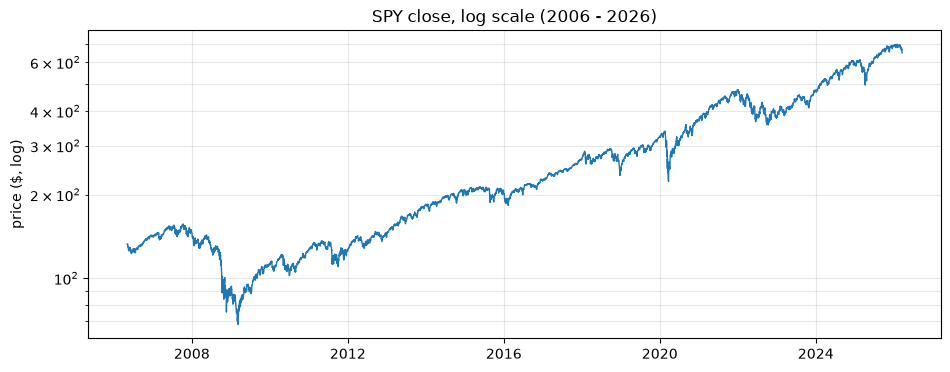

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(spy.index, spy['close'], lw=1)
ax.set_yscale('log')
ax.set_title("SPY close, log scale (2006 - 2026)")
ax.set_ylabel("price ($, log)")
ax.grid(True, which='both', alpha=0.3)
plt.show()

## Plot 2: the distribution of daily returns

A **return** is the percent change from one close to the next. The histogram
below is the shape of the problem we are up against.

mean daily return: 0.0393%   std: 1.2280%
within +/-1 std:   80.4%   (a normal 'bell curve' would be ~68%)


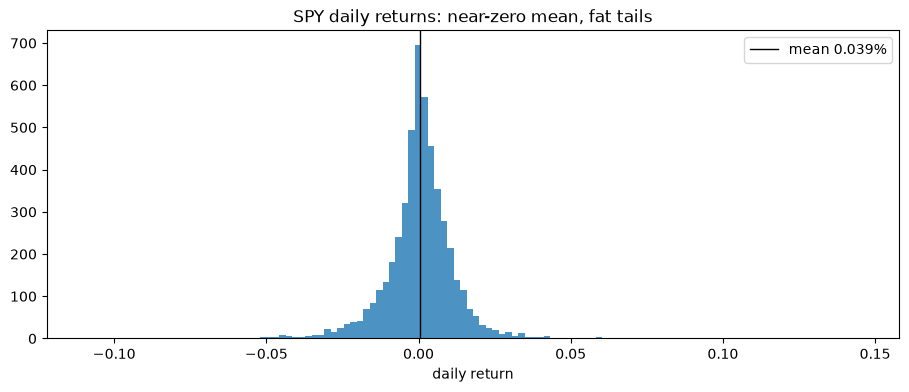

In [6]:
# .pct_change() turns a price series into returns: (today's close / yesterday's
# close) - 1, for every row. The very first row has no "yesterday", so it comes
# out as NaN (not-a-number); .dropna() drops that one empty row.
ret = spy['close'].pct_change().dropna()

# mean  = the typical daily drift (how much the average day moves).
# std    = standard deviation, the typical SIZE of a day's swing around that mean.
print(f"mean daily return: {ret.mean():.4%}   std: {ret.std():.4%}")

# Fraction of days whose move lands within one std of zero. A bell curve would put
# ~68% here; our fat-tailed data packs in more, because the center is more peaked.
within_1std = (ret.abs() <= ret.std()).mean()
print(f"within +/-1 std:   {within_1std:.1%}   (a normal 'bell curve' would be ~68%)")

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(ret, bins=120, alpha=0.8)            # bars = how often each return size happened
ax.axvline(ret.mean(), color='k', lw=1, label=f"mean {ret.mean():.3%}")
ax.set_title("SPY daily returns: near-zero mean, fat tails")
ax.set_xlabel("daily return")
ax.legend()
plt.show()

**Read it, and notice how _narrow_ it is.** The whole story is in the printout
above and the shape below:

- The **mean** is a hair above zero (a few hundredths of a percent per day). The
  market drifts up, but only barely, day to day.
- The **standard deviation** is about **&plusmn;1.2%** (see the printout): that is the
  typical size of a single day's move. About **four days in five (~80%)** land
  inside that one-sigma band, and almost everything piles into the thin spike
  around zero.
- The rare bars far out on the left and right are the **fat tails**: the occasional
  crash or rip. They are uncommon, but they are where the drama lives.

**What "fat tails" actually means.** A bell curve (the normal distribution) is the
default mental model for "random," and it would put about **68%** of days inside
one sigma. Our data packs in **~80%**, noticeably more. That is not a
contradiction, it is the whole point: returns are **not** normal, they are
*leptokurtic*, meaning the distribution is **both** more peaked in the middle
**and** heavier in the tails than a bell curve. Picture squeezing a bell curve:
mass leaves the "shoulders" (the moderate &plusmn;1 to &plusmn;2 sigma moves) and goes two
places at once, into the tall central spike of boringly small days and out into
the rare extreme days. So calm days are *more* common than "normal" predicts, and
violent days are *also* more common; it is the in-between, ordinary-sized move that
is rarer. A 5-sigma day, which a bell curve calls a once-in-a-millennium event,
shows up every few years in real markets.

**Why it matters here.** Two consequences run through the rest of the course.
First, the central spike is so dominant that the tiny upward drift we would love to
predict is buried under noise many times its size, which is why, in Section 1,
asking a model to call *tomorrow's direction* lands near a coin flip, and why we
later stop predicting direction and switch to **filtering a known signal**. Second,
the heavy tails are exactly the risk a backtest is tempted to ignore: a strategy
with no stop-loss can look serene for years and then meet a left-tail day that a
normal-distribution risk model swore was impossible (the drawdown plot below makes
those days concrete). **Analogy:** most days are *static on the radio*; the music,
and the danger, both live in the rare tails.

## Plot 3: drawdowns, or "how bad did it get?"

Return is only half the story; the other half is **risk**. A **drawdown** is how
far below its previous peak an investment sat at each moment, as a percent. Picture
the equity curve as a hiker walking a mountain range: the drawdown is how far below
the highest point reached *so far* the hiker currently stands. It is zero at every
new peak and negative everywhere else.

We build it in three small steps, which the code mirrors line for line:

1. **Grow $1.** Turn the daily returns into an equity curve: the value of $1
   invested, compounding day after day.
2. **Track the high-water mark.** At each day, remember the highest the curve has
   ever reached up to that point.
3. **Measure the gap.** The drawdown is how far the curve sits below that
   high-water mark, in percent (always zero or negative).

The deep troughs below are 2008 (about -56%) and 2020 (about -34%).

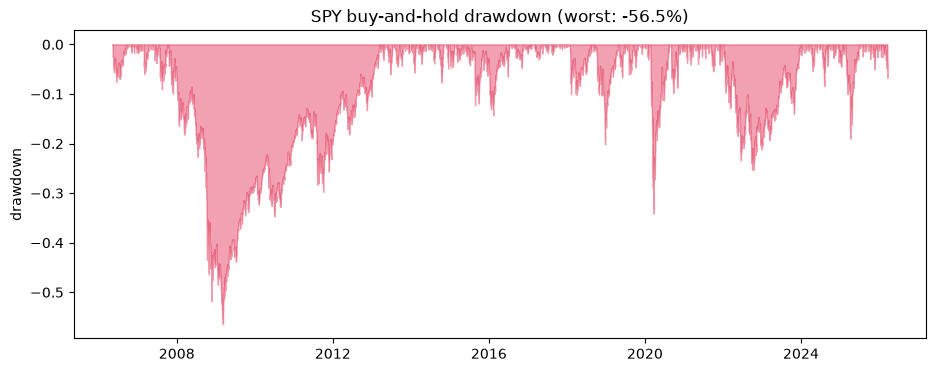

In [7]:
# Step 1, grow $1. Each day multiplies the running total by (1 + that day's return).
# .cumprod() is the "cumulative product": it chains all those daily multipliers
# together, so curve[t] is what $1 had grown to by day t.
curve = (1 + ret).cumprod()

# Step 2, the high-water mark. .cummax() is the "cumulative maximum": at each day it
# reports the largest value the curve has reached up to and including that day.
peak = curve.cummax()

# Step 3, the gap below the peak, as a percent. curve / peak is 1.0 at a fresh high
# (drawdown 0) and less than 1.0 when underwater, so subtracting 1 gives 0 or a
# negative number: exactly how far below the prior peak we are.
drawdown = curve / peak - 1.0         # always <= 0

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(drawdown.index, drawdown, 0, color='crimson', alpha=0.4)
ax.set_title(f"SPY buy-and-hold drawdown (worst: {drawdown.min():.1%})")
ax.set_ylabel("drawdown")
plt.show()

**Why it matters:** these troughs make later metrics (Sharpe, Sortino, max
drawdown) concrete, and they explain a danger we will meet in the Connors RSI(2)
strategy, which famously uses **no stop-loss**. "No stop" is comfortable in a
gentle uptrend and catastrophic in a 2008. Seeing the drawdowns now means we
will not be surprised later.

## The one rule: no look-ahead

Every result in this course obeys the **no-look-ahead contract**. Break it and
your backtest becomes fiction.

1. A feature or signal at bar *t* uses data **only up to bar _t_'s close**.
2. Forward-looking data is allowed in **exactly one** place: the label (the
   answer key we train against), and never as an input.
3. **Execution lags by one bar.** A decision made at *t*'s close is applied to
   the *t &rarr; t+1* return. You cannot know today's closing RSI until the close
   has actually printed, so the earliest you can act on it is the *next* bar.
   Throughout this course we model a **market-on-close** fill: a position chosen
   at *t*'s close earns the close-to-close return from *t* to *t+1*. (Our backtest
   does this with a one-bar `shift`; see `evaluation.backtest_positions`.)

Two analogies for **look-ahead bias**, the sin of letting the future leak in:

- **The crossword done in pen by a cheater** who peeks at tomorrow's printed
  solutions. Flawless on paper, useless live.
- **Betting on a horse race after watching the replay.** Your "system" wins
  every test because it already saw the finish.

The cell below makes the cost of cheating literal.

In [8]:
# up_today is 1 on days SPY closed up, 0 otherwise. The catch: it is built FROM
# today's return (ret > 0), so it already "knows" today's answer. (.astype(int)
# just turns each True/False into 1/0 so we can multiply by it below.)
up_today = (ret > 0).astype(int)

# WRONG (cheating). Multiply today's signal by today's return. Because up_today is
# 1 exactly on the up days and 0 on the down days, this keeps every up day's gain
# and zeros out every loss: we are "buying" only the days we already know closed
# green. Impossible in real life (you cannot see today's close before it happens),
# so this edge is a fantasy. .dropna() just trims empty rows.
look_ahead = (up_today * ret).dropna()

# RIGHT (honest). .shift(1) slides the signal forward one day, so TODAY we act on
# YESTERDAY's known direction, applied to today's return. That is the one-bar
# execution lag from the contract above: a signal at close t can only be traded at
# t+1. With that single shift, the fake edge evaporates.
honest = (up_today.shift(1) * ret).dropna()

ann = 252  # trading days per year, just to scale the per-day numbers into per-year
print(f"look-ahead 'strategy' (cheating): {look_ahead.mean():.4%}/day  ~ {look_ahead.mean()*ann:.0%}/yr")
print(f"honest version (shifted by 1):    {honest.mean():.4%}/day  ~ {honest.mean()*ann:.1%}/yr")
print("\nSame data, same feature. A one-bar shift is the only difference, and it turns")
print("an absurd 'edge' into ~nothing. That .shift(1) is the line between a fantasy")
print("backtest and an honest one.")

look-ahead 'strategy' (cheating): 0.4134%/day  ~ 104%/yr
honest version (shifted by 1):    0.0024%/day  ~ 0.6%/yr

Same data, same feature. A one-bar shift is the only difference, and it turns
an absurd 'edge' into ~nothing. That .shift(1) is the line between a fantasy
backtest and an honest one.


## A peek at the hourly data

We also ship SPY **hourly** bars. They only go back to 2023, so they cannot
support a 20-year study. We reserve them for Section 8, where we ask whether an
intraday reading can *confirm* a daily signal. For now, just confirm they load.

In [9]:
spy_h = data.load_spy_hourly()
print("hourly shape:", spy_h.shape)
print("hourly range:", spy_h.index.min(), "->", spy_h.index.max())
spy_h.head(3)

hourly shape: (5000, 6)
hourly range: 2023-05-10 10:30:00 -> 2026-03-20 14:30:00


,symbol,open,high,low,close,volume
datetime,,,,,,
2023-05-10 10:30:00,spy,411.91,412.42,410.90,411.39,1323560.0
2023-05-10 11:30:00,spy,411.39,411.50,408.97,409.22,1325863.0
2023-05-10 12:30:00,spy,409.22,411.25,408.87,410.99,1661745.0


## Pitfalls that silently break market-data loading

A checklist worth re-reading whenever you load a new file:

- **Timezones / odd stamps.** These daily bars are stamped `08:30` (a data-export
  artifact), so we normalize to the date. Always know your timezone.
- **Duplicate bars.** Dedupe on the timestamp; exports sometimes repeat a row.
- **Holiday gaps.** ~252 trading days/year. Never `reindex` to continuous calendar
  days; it injects fake bars and forward-fill artifacts.
- **Sorting.** Never assume the CSV is chronological. Out-of-order data makes
  rolling windows silently wrong.
- **Survivorship.** Using a basket of "today's winners" over history inflates
  results. One index ETF (SPY) sidesteps it.

## Recap and what's next

You loaded SPY cleanly, saw that daily returns are mostly noise, saw how bad
drawdowns get, and learned the one rule: **no look-ahead**. Next, **Section 1**
puts a model to the obvious first question, *can it predict tomorrow's
direction?*, and watches it land on a coin flip. That failure is what motivates
everything after it.